<a href="https://colab.research.google.com/github/riya-rajbhut/music-ai/blob/main/rnn_lstm_basic_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 54.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=be5b3741304dd0144813751eabed46819ccec271b08379c91de850f3503b3436
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


# Step 1: Parse the MIDI data
We need to translate raw MIDI files into three core variables:
**Pitch** (the note), **Step** (time since the last note), and **Duration** (how long the note is held).

In [ ]:
import pretty_midi
import collections
import numpy as np
import tensorflow as tf

def midi_to_notes(midi_file: str) -> dict:
    pm = pretty_midi.PrettyMIDI(midi_file)
    # We focus on the main instrument (the piano)
    instrument = pm.instruments[0]
    notes = collections.defaultdict(list)

    # Sort notes by start time
    sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
    prev_start = sorted_notes[0].start

    for note in sorted_notes:
        start = note.start
        end = note.end
        notes['pitch'].append(note.pitch)
        notes['step'].append(start - prev_start)
        notes['duration'].append(end - start)
        prev_start = start

    return notes

In [ ]:
import pathlib
import tensorflow as tf

# 1. Download and extract the file, capturing the returned path to the zip file
zip_path = tf.keras.utils.get_file(
    'maestro-v3.0.0-midi.zip',
    origin='https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip',
    extract=True,
    cache_dir='.', cache_subdir='data',
)

# 2. Point to the actual extracted folder inside 'data/'
# Keras extracts the archive contents directly into 'data/', which contains the 'maestro-v3.0.0' folder

#!dir /s data
#!ls -R data/
import pathlib

# 1. Update this to the actual folder path shown in your file listing
data_dir = pathlib.Path('data/maestro-v3_extracted/maestro-v3.0.0')

# 2. Fix the glob pattern to look recursively (**/) through the subfolders
filenames = list(data_dir.glob('**/*.mid*'))

print('Number of files found:', len(filenames))


Number of files found: 1276


In [ ]:
import glob

# 1. Find some MIDI files from your downloaded MAESTRO dataset
# (Make sure to replace 'path_to_maestro_folder' with your actual folder path)
midi_files = glob.glob(str(data_dir) + "/**/*.mid*", recursive=True)
print('Number of midi_files found:', len(midi_files))

# For now, let's just grab the first 3 files to test and keep things fast
sample_files = midi_files[:3]
print('Number of sample_files found:', len(sample_files))

all_pitches = []

# 2. Extract the pitches from these files and combine them into one big list
for file in sample_files:
    try:
        raw_notes = midi_to_notes(file)
        all_pitches.extend(raw_notes['pitch'])
    except Exception as e:
        print(f"Skipping broken file {file}: {e}")

print(f"Total number of notes collected for training: {len(all_pitches)}")

# ==========================================
# Now, the rest of your Step 2 code will work!
# ==========================================
sequence_length = 50
vocab_size = 128

X = []
y = []

for i in range(len(all_pitches) - sequence_length):
    X.append(all_pitches[i:i + sequence_length])
    y.append(all_pitches[i + sequence_length])

X = np.array(X)
y = np.array(y)

# Normalize and One-Hot Encode
X_normalized = np.expand_dims(X, axis=-1) / float(vocab_size) # Added expand_dims to shape it correctly for LSTM (samples, steps, features)
y_encoded = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

print("X shape:", X_normalized.shape)
print("y shape:", y_encoded.shape)

Number of midi_files found: 1276
Number of sample_files found: 3
Total number of notes collected for training: 10210
X shape: (10160, 50, 1)
y shape: (10160, 128)


# Step 2: Create Sequences for the Model
An **LSTM** needs a historical window to learn from. Let's look at windows of **50 notes** to predict the **51st note**.

For simplicity in this starter code, we will focus just on **training** the model to **predict** the next pitch.

In [36]:
# Assume 'all_pitches' is a flat list of all note pitches across your files
sequence_length = 40  # Memory Window ==> How many notes from the last sequence should be stored in-memory
vocab_size = 128 # dictionary size ==> MIDI notes scale from 0 to 127. There are exactly 128 possible notes a piano can play.

X = []  # inputs for AI model
y = []  # Outputs AI model spits out

for i in range(len(all_pitches) - sequence_length):
    # Take a window of 50 notes
    X.append(all_pitches[i:i + sequence_length])
    # The target is the very next note
    y.append(all_pitches[i + sequence_length])

X = np.array(X)
y = np.array(y)

# Normalize X data to sit between 0 and 1 for easier neural network math
X_normalized = X / float(vocab_size)
# One-hot encode the target outputs
y_encoded = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

print("X shape:", X_normalized.shape)
print("y shape:", y_encoded.shape)

X shape: (10170, 40)
y shape: (10170, 128)


Let's now visualize how X and Y are kept in memory

In [ ]:
!pip install matplotlib seaborn

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


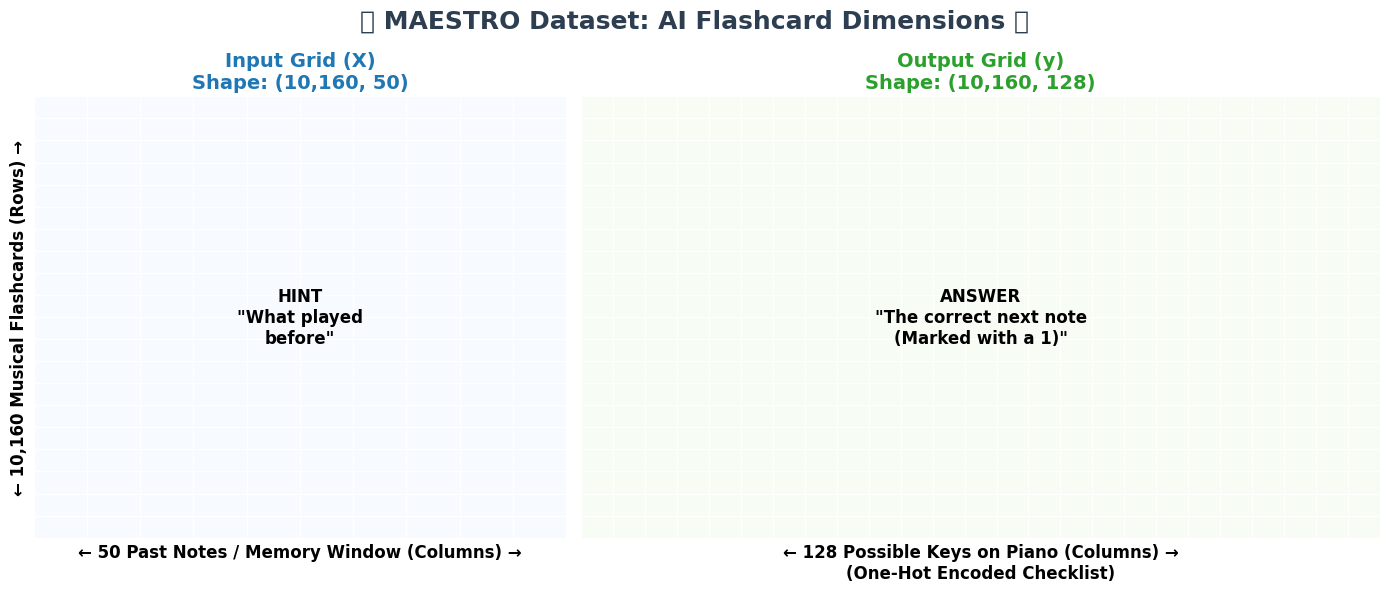

 📝 JUPYTER REFERENCE CHEAT SHEET 
🔹 X Shape: (10160, 50)  --> 10,160 examples. Each is a timeline of 50 consecutive notes.
🔹 y Shape: (10160, 128) --> 10,160 answers. Each is a row of 128 piano keys where
                             only ONE key is active (1) and the rest are quiet (0).


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Let's create a beautiful visual explanation of your shapes!
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.5]})
fig.suptitle('🎵 MAESTRO Dataset: AI Flashcard Dimensions 🎵', fontsize=18, fontweight='bold', color='#2c3e50')

# ---- 1. VISUALIZING X SHAPE ----
# Draw a box representing the 10160 rows by 50 columns
X_block = np.ones((20, 10)) # Symbolic grid for drawing
sns.heatmap(X_block, ax=axes[0], cbar=False, cmap='Blues', linewidths=0.5, linecolor='white', xticklabels=False, yticklabels=False)
axes[0].set_title('Input Grid (X)\nShape: (10,160, 50)', fontsize=14, fontweight='bold', color='#1f77b4')
axes[0].set_ylabel('← 10,160 Musical Flashcards (Rows) →', fontsize=12, fontweight='bold')
axes[0].set_xlabel('← 50 Past Notes / Memory Window (Columns) →', fontsize=12, fontweight='bold')
axes[0].text(5, 10, 'HINT\n"What played\nbefore"', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

# ---- 2. VISUALIZING Y SHAPE ----
# Draw a box representing the 10160 rows by 128 columns
y_block = np.ones((20, 25)) # Symbolic wider grid for drawing
sns.heatmap(y_block, ax=axes[1], cbar=False, cmap='Greens', linewidths=0.5, linecolor='white', xticklabels=False, yticklabels=False)
axes[1].set_title('Output Grid (y)\nShape: (10,160, 128)', fontsize=14, fontweight='bold', color='#2ca02c')
axes[1].set_xlabel('← 128 Possible Keys on Piano (Columns) →\n(One-Hot Encoded Checklist)', fontsize=12, fontweight='bold')
axes[1].text(12.5, 10, 'ANSWER\n"The correct next note\n(Marked with a 1)"', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ---- JUPYTER NOTEBOOK TEXT CHEAT SHEET ----
print("="*65)
print(" 📝 JUPYTER REFERENCE CHEAT SHEET ")
print("="*65)
print(f"🔹 X Shape: (10160, 50)  --> 10,160 examples. Each is a timeline of 50 consecutive notes.")
print(f"🔹 y Shape: (10160, 128) --> 10,160 answers. Each is a row of 128 piano keys where")
print(f"                             only ONE key is active (1) and the rest are quiet (0).")
print("="*65)

# Phase 3: Building & Training the LSTM
We'll build a sequential model with an Embedding layer (helps the network learn relationships between notes), an LSTM layer, and a Dense layer with a Softmax activation function to output probabilities for the next note.

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Initialize an empty brain architecture
model = Sequential([

    # 2. Layer 1: The Musical Map (Embedding)
    # (Turns note numbers into meaningful mathematical relationships)
    # Our embedding layer needs 128 slots to assign to those keys.
    # every note will be described using 64 distinct mathematical traits (e.g., how bright it sounds, how bass-heavy it is, how often it follows a C chord).
    Embedding(input_dim=128, output_dim=64, input_length=50),

    # Embedding(128, 64) layer creates a giant grid of random decimal numbers. Every single one of the 128 keys gets assigned 64 random decimals.
    # So, 64 are the weights

    # 3. Layer 2: The Musical Memory (LSTM)
    # (Remembers the rhythm and melody over time)
    # 256 is large enough to capture the elegant flow of the MAESTRO classical dataset, but small enough that your Jupyter Notebook (especially if you're using a free Google Colab GPU) can train it in minutes rather than days.
    LSTM(256, return_sequences=False),

    # 4. Layer 3: The Anti-Cheating Filter (Dropout)
    # (Forces the network to actually learn patterns instead of memorizing)
    # "During training, randomly turn off 30% of the neurons (the memory tracks) on every single step."
    Dropout(0.3),

    # 5. Layer 4: The Final Guessing Sheet (Dense + Softmax)
    # (Outputs 128 probabilities, one for each possible piano key)
    Dense(128, activation='softmax')
])

# 6. Tell the brain how to learn from its mistakes
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print out the blueprint of our newly built brain
model.summary()

# Above will not show anything because Keras use 'lazy initialization' which means it doesn't start training immediately after declaring.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# 5. START TRAINING!
# We'll run for 12 epochs. Adjust batch_size based on your computer's memory.
print("\n🎵 Starting Training Loop... Sit back and listen to the silence while the AI learns! 🎵\n")
history = model.fit(X, y_encoded, epochs=10, batch_size=64)


🎵 Starting Training Loop... Sit back and listen to the silence while the AI learns! 🎵

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 34s 197ms/step - accuracy: 0.0434 - loss: 3.9891
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 34s 212ms/step - accuracy: 0.0659 - loss: 3.7589
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.0880 - loss: 3.5967
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.0949 - loss: 3.4806
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.1057 - loss: 3.4133
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.1137 - loss: 3.3450
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 43s 208ms/step - accuracy: 0.1244 - loss: 3.2788
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.1333 - loss: 3.2195
Epoch 9/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.1461 - loss: 3.1639
Epoch 10/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.1585 - loss: 3.1113


# Phase 4: Generating Brand New Music!
Now that your model is trained, we give it a 50-note "seed" sequence from our dataset, and ask it to start dreaming up the next 100 notes.

In [40]:
print("🎹 Generating brand new music notes... 🎹")

# 1. Grab a random 50-note starting sequence from your original X data to act as a seed
random_index = np.random.randint(0, len(X) - 1)
seed_sequence = list(X[random_index])

generated_notes = []

# 2. Prediction loop
for i in range(100): # Change 100 to generate a longer or shorter piece
    # Format the current 50-note seed sequence into a batch of 1
    input_eval = np.reshape(seed_sequence, (1, sequence_length))

    # Ask the AI to guess the probabilities for the next note
    predictions = model.predict(input_eval, verbose=0)

    # Add creative randomness! Instead of picking the absolute highest percentage,
    # we sample from the probability distribution.
    predicted_id = np.random.choice(128, p=predictions[0])

    # Save our newly generated note
    generated_notes.append(predicted_id)

    # Slide our memory window forward: Add the new note, drop the oldest note
    seed_sequence.append(predicted_id)
    seed_sequence = seed_sequence[1:]

print(f"🎉 Done! Generated {len(generated_notes)} notes successfully.")

🎹 Generating brand new music notes... 🎹
🎉 Done! Generated 100 notes successfully.


# Phase 5: Saving the Music to a Playable MIDI File
Finally, we take that list of 100 numbers generated by the AI and transform them back into a .mid file that you can listen to or import into production software (like GarageBand, FL Studio, or MuseScore).

In [41]:
import pretty_midi

# 1. Initialize a blank MIDI file container
new_midi = pretty_midi.PrettyMIDI()

# 2. Choose an instrument (Program 0 is a standard Acoustic Grand Piano)
piano_program = pretty_midi.instrument_name_to_program('Acoustic Grand Piano')
piano = pretty_midi.Instrument(program=piano_program)

# 3. Create a timeline loop to lay down the notes sequentially
time_counter = 0.0

for pitch in generated_notes:
    # We will give every single note a standard duration and step (0.4 seconds)
    # so you can hear the raw melodic progression clearly.
    note = pretty_midi.Note(
        velocity=90,          # Volume (0 = silent, 127 = striking the key violently)
        pitch=int(pitch),      # The MIDI key number generated by our AI
        start=time_counter,    # When the note starts pressing down
        end=time_counter + 0.4 # When the note lifts back up
    )

    # Append the note to our digital piano tracks
    piano.notes.append(note)

    # Advance our timeline forward by 0.4 seconds for the next note
    time_counter += 0.4

# 4. Attach the piano track to our MIDI file
new_midi.instruments.append(piano)

# 5. Save the file directly to your workspace!
output_filename = 'my_first_ai_composition.mid'
new_midi.write(output_filename)

print(f"🚀 SUCCESS! Your AI song has been saved as: '{output_filename}'")
print("You can download this file from your notebook workspace and play it!")

🚀 SUCCESS! Your AI song has been saved as: 'my_first_ai_composition.mid'
You can download this file from your notebook workspace and play it!


**Step 1: Install the playback library**

**Step 2: Run the Playback Code**
It will load the newly generated my_first_ai_composition.mid file and play it out loud through the speakers!

In [ ]:
import pretty_midi
import numpy as np
from IPython.display import Audio

# 1. Load the generated MIDI file using pretty_midi
pm = pretty_midi.PrettyMIDI(output_filename)

# 2. Synthesize the MIDI notes into a raw audio waveform (defaults to simple synth waves)
# We set the sampling rate to 16,000 Hz for quick rendering
sampling_rate = 16000
audio_data = pm.synthesize(fs=sampling_rate)

# 3. Use Jupyter's built-in Audio player to play the raw array
print("🎵 Synthesized successfully! Click play below to hear your AI composition:")
Audio(audio_data, rate=sampling_rate)

🎵 Synthesized successfully! Click play below to hear your AI composition:
